# Data Augmentation MCMC

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/gem-epidemics/colab/blob/master/iddinf/data_augmentation_mcmc.ipynb)




$$
\newcommand{\thetab}{\boldsymbol{\theta}}
\newcommand{\Xb}{\boldsymbol{X}}
\newcommand{\yb}{\boldsymbol{y}}
$$

## Introduction
What makes performing inference for epidemic models hard is the fact that there is lots of missing information. E.g. we almost never observe when individuals get infected, only when they develop symptoms or recover (or are removed) from the population.

To rigorously fit epidemic models to observed data we need to account for this when performing inference. One way to do this is with what's known as the **Metropolis within Gibbs** algorithm.

**Metropolis within Gibbs algorithm:**

This is essentially a two-step Gibbs algorithm that draws samples from the joint posterior distribution $\pi(\theta,X|y)$ of the parameters $\theta$ and the unobserved (complete) states $X$ given the observed (incomplete) data $y$:

1. Draw $\theta\sim\pi(\theta|X,y)$
2. Draw $X\sim\pi(X|\theta,y)$

It is called Metropolis within Gibbs as one or more of the Gibbs updates in the Gibbs sampler are replaced by a Metropolis-Hastings update. It is used when a conditional posterior distribution cannot be sampled from directly, but can be targeted using a Metropolis-Hastings step. E.g. the conditional posterior distribution of the unobserved states $X$ is typically not available in closed form, so step 2 is implemented using a Metropolis-Hastings update targeting $\pi(X\mid\theta,y)$.

## Part I -- moving events

In [113]:
from warnings import warn

try:
    import google.colab
    !pip install gemlib
except:
    warn("Not running in Colab, make sure `gemlib` is installed locally")

/var/folders/36/s7ymq7cn18bf5x8xvy9dz0700000gn/T/ipykernel_52841/2922310410.py:7: UserWarning: Not running in Colab, make sure `gemlib` is installed locally
  warn("Not running in Colab, make sure `gemlib` is installed locally")


In [114]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
from typing import NamedTuple
from matplotlib.lines import Line2D

from scipy.spatial.distance import pdist, squareform
import tensorflow_probability.substrates.jax as tfp

import gemlib
from gemlib.distributions import DiscreteTimeStateTransitionModel

tfd = tfp.distributions

%matplotlib inline

DTYPE = np.float32
ArrayLike = np.typing.ArrayLike

### Learning outcomes

* Understand what censored event data is, and why it presents a challenge for parameter inference
* Understand how to fit epidemic models to censored event data
* Understand in principle how the move events algorithm works

### Introduction


Generally, outbreak data only captures a partially observed epidemic process. As there are time-dependent quantities in the likelihood we cannot evaluate it with missing event times. One way of tackling censored data is to use a likelihood-free method of conducting inference (such as [ABC](https://gem-epidemics.gitlab.io/practical-epidemics/iddinf/approximate_bayesian_computation.html)).

Alternatively, we can try to augment the data to estimate the unobserved epidemiological event times. In a Bayesian setting we can simply treat missing event (transition) times as parameters to be estimated.

A fully observed epidemic at a metapopulation level would mean we know how many units experienced an event at each time point.

At an individual level, the time of each of their epidemic events (transitions between states) would be recorded. This might look something like this:



In [115]:
import pandas as pd

unit_id = np.arange(0,10)
infection_times = np.random.randint(low=1, high=20, size=10).astype(np.float32)
removal_times = np.random.randint(low=1, high=20, size=10).astype(np.float32)

line_list = pd.DataFrame({'unit_id': unit_id,
                        'SI transition time': infection_times,
                        'IR transition time': removal_times}
                        ).set_index('unit_id')
line_list

,SI transition time,IR transition time
unit_id,,
0,4.0,11.0
1,4.0,14.0
2,1.0,16.0
3,13.0,14.0
4,11.0,6.0
5,4.0,16.0
6,2.0,2.0
7,1.0,5.0
8,1.0,9.0


Whereas data from a partially observed epidemic, with missing infection times for example, would look more like this:


In [116]:
unobserved_infection_times = np.nan

censored_line_list =pd.DataFrame({'unit_id': unit_id,
                        'SI transition time': unobserved_infection_times,
                        'IR transition time': removal_times}
                        ).set_index('unit_id')
censored_line_list

,SI transition time,IR transition time
unit_id,,
0,NaN,11.0
1,NaN,14.0
2,NaN,16.0
3,NaN,14.0
4,NaN,6.0
5,NaN,16.0
6,NaN,2.0
7,NaN,5.0
8,NaN,9.0


This morning, we will think about how we can estimate missing infection times by adding them as parameters to a MCMC algorithm.

### Example model: the spatial individual-level SIR model

We'll take as our example a spatially-explicit population of 50 individuals.  We'll then let the force of infection between individuals depend on distance.

#### Defining a spatial population

First, let's simulate the spatial population structure, assuming _complete spatial randomness_, i.e. that individuals are distributed uniformly over a study region.

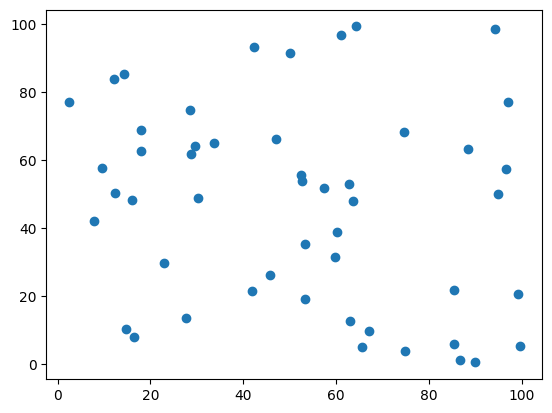

In [117]:
# Defining epidemic model parameters
POPSIZE = 50

coords = jax.random.uniform(
    jax.random.key(0), minval=0.0, maxval=100.0, shape=[POPSIZE, 2]
)
plt.plot(coords[:,0], coords[:,1], "o")

Now we'll compute the pairwise distances between all points to give a `[POPSIZE,POPSIZE]` distance matrix.

In [118]:
distance_matrix = squareform(pdist(coords))

#### A spatial SIR model

For the purposes of exposition, we'll define a spatial SIR model, i.e. one in which the force of infection is determined by the spatial relationship between individuals.  In particular, we'll assume that
$$
\lambda^{SI}_i(t, X) = \beta \sum_{j=1}^{N} \mathbf{1}_{\{x^{I}_{jt} = 1\}}e^{-\phi d_{ij}}
$$
where $d_{ij}$ is the (Euclidean) distance between $i$ and $j$.

As usual, we define the initial state (with the initial infected individual), SIR incidence matrix, and the SIR model factory function.

In [119]:
def spatial_sir(beta, phi, gamma, initial_state, name):

    incidence_matrix = np.array(
        [ #  SI  IR
            [-1,  0],  # S
            [ 1, -1],  # I
            [ 0,  1], # R
        ],
    )

    def si_rate(t, state):
        return beta * jnp.matvec(jnp.exp(-phi * distance_matrix), state[:, 1])

    def ir_rate(t, state):
        return gamma

    return DiscreteTimeStateTransitionModel(
        transition_rate_fn=[si_rate, ir_rate],
        incidence_matrix=incidence_matrix,
        initial_state=initial_state,
        num_steps=75,
        name=name,
    )

Now we construct the overall Bayesian probabilistic model, encapsulating any covariate data (including, in this case, the initial conditions), and placing priors on the parameters $\beta$, $\phi$, and $\gamma$.

In [120]:
@tfd.JointDistributionCoroutineAutoBatched
def model():

    # Constants
    initial_state = np.concatenate(
        [
            [[0, 1, 0]], # Initial infected
            np.repeat([[1, 0, 0]], POPSIZE-1, axis=0) # Everybody else susceptible
        ],
        axis=0,
    )

    # Prior
    beta = yield tfd.Gamma(
      concentration=3.0, rate=2.0, name="beta",
    )

    phi = yield tfd.Gamma(
      concentration=0.1, rate=0.1, name="phi"
    )

    gamma = yield tfd.Gamma(
      concentration=2.0, rate=1.0, name="gamma"
    )

    yield spatial_sir(beta, phi, gamma, initial_state, name="sir")

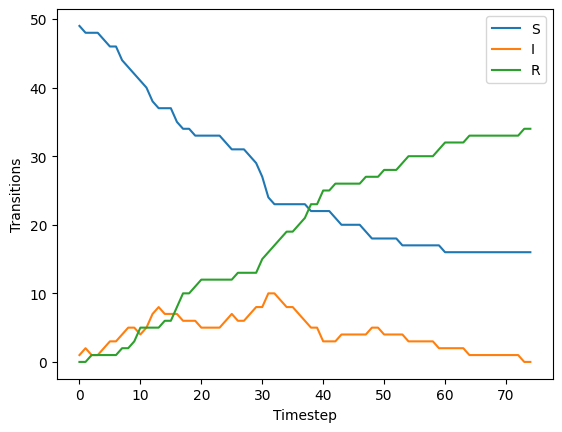

In [121]:
# simulate from the epidemic model to provide initial event times for fitting
dists, sim = model.sample_distributions(beta=0.1, phi=0.1, gamma=0.14, seed=jax.random.key(4))
sim_state = dists.sir.compute_state(sim.sir)

plt.plot(np.sum(sim_state, axis=1), label=["S", "I", "R"])
plt.xlabel("Timestep")
plt.ylabel("Transitions")
plt.legend()

### The Move algorithm

The move algorithm explores the posterior distribution of the censored event times. If we were modelling SARS-CoV-2, a likely set of infection data may be positive test results. We could assume that from the testing dataset we know which individuals were infected. However, the testing data would not provide the time that inidividuals were initially infected. We could therefore provide some initial infection times for each individual who tested positive and use a move algorithm to estimate their SI transition event (infection time).

The move algorithm for a discrete-time SIR model is shown in Algorithm {prf:ref}`alg-move-events`.



```{prf:algorithm} The move events algorithm for an individual-level model
:label: alg-move-events

**Input:** $q(\cdot)$ proposal distribution, $\pi(\cdot)$ a target distribution

**Initialise:** $z^{0}$


1. Choose an event, time *t* and unit *i*, to move:

$$t, i \sim \mbox{Uniform}\{t, i: z_{it}>0\}$$

2. Choose a new time to which to move the event:

 $$t^\prime \sim \mbox{Discrete}(\mathcal{T})$$
 where $\mathcal{T} = \{0\,\dots,T-1\} \cap \{t-\delta_{max},\dots,t+\delta_{max}\} \setminus \{t\}$, i.e. the set of times $t \pm \delta_{max}$ which does _not_ include $t$ or allow us to propose outside the time window represented by the specified model.

3. Update event matrix. Let:

$$z^\star_{it} = z_{it} - 1$$

$$z_{it^\prime + \delta}^\star = z_{it^\prime} + 1$$


4. Compute the acceptance probability

$$\alpha(z, z^\star) = 1 \wedge \frac{\pi(z^\star | \cdot)q(z | z\star)}{\pi(z | \cdot)q(z^\star|z)}$$

As we are using a symmetric proposal for the event moves, the q ratio cancels. i.e. $||z_{it}^\star > 0|| = ||z_{it} > 0||$

```

### Hand-coding the Move algorithm

In this section, we've set an exercise for you to code up Algorithm {prf:ref}`alg-move-events`.  For now, we'll just focus on exploring the posterior distribution over the $S\rightarrow I$ transition for each individual in our population, assuming (unrealistically) that we know the values of the parameters $\beta$, $\phi$, and $\gamma$.  In the next section we'll demonstrate how to it in a Metropolis-within-Gibbs sampler capable of sampling from the entire joint posterior distribution over the parameters and $S\rightarrow I$ together.

For the following exercise, we'll condition the model on "known" values of $\beta$, $\phi$, and $\gamma$, and retrieve the (un-normalized) conditional posterior distribution function for the event times  

````{exercise-start}
:label: da-ex.1
````

Code a move algorithm for infection times

1. Using the simulated epidemic output above, try to move an event time in event_list.

> You can copy the code outline below as a guide to coding your own move algorithm. Alternatively, take another look at the algorithm definition, try it your own way and compare with the solution at the end.

```
import random

event_list = np.array(sim.sir)
# Let's start by only moving one transition event with a maximum time delta of 2
num_moves = 1
delta_max = 2

# locate the index positions for the SI events in event_list [T, N metapopulations, L transitions]
valid_events = np.where(#fill in )

# choose which of these events to move
index_events_to_move = random.sample(#fill in )

# we can access the current value of the event we want to move.
current_time = valid_events[0][index_events_to_move[0]]
unit = valid_events[1][index_events_to_move[0]]

# check the current value of the event we're about to move
print(event_list[#fill in])

# direction of the move: forward (+1) or backward (-1)
move_direction = # fill in

# time delta for the move: an integer from 1 to delta_max, inclusive
time_delta = # fill in

# proposed new time for the event
updated_time_index = #fill in

# only apply the move if the new time is within the observation window
if # fill in
    event_list[#fill in]        # remove the event from its old time
    event_list[#fill in]        # add it at the new time

# check that the event has moved: should be a 1 in the updated time and 0 at the old time
print(#fill in )
print(#fill in )
```


````{exercise-end}
````

````{solution-start} da-ex.1
:class: dropdown
````

In [122]:
event_list = np.array(sim.sir)

In [123]:
import random

# Let's start by only moving one transition event with a maximum time delta of 2
num_moves = 1
delta_max = 2

# locate the index positions for the SI events in event_list [T, N metapopulations, L transitions]
valid_events = np.where(event_list[:, :, 0] > 0)

# choose which of these events to move
index_events_to_move = random.sample(range(0, valid_events[0].shape[0]), num_moves)

In [124]:
current_time = valid_events[0][index_events_to_move[0]]
unit = valid_events[1][index_events_to_move[0]]

# look at the current value of the event we're about to move
print(event_list[current_time, unit, 0])

1.0


In [125]:
# direction of the move: forward (+1) or backward (-1)
move_direction = np.random.choice([-1, 1])

# time delta for the move: an integer from 1 to delta_max, inclusive
time_delta = np.random.randint(1, delta_max + 1)

# proposed new time for the event
updated_time_index = current_time + time_delta * move_direction

# only apply the move if the new time is within the observation window
if 0 <= updated_time_index <= event_list.shape[0] - 1:
    event_list[current_time, unit, 0] -= 1        # remove the event from its old time
    event_list[updated_time_index, unit, 0] += 1  # add it at the new time

In [126]:
# check that the event has moved: count at the old time drops, count at the new time increases
print(f"count at old time ({current_time}): {event_list[current_time, unit, 0]}")
print(f"count at new time ({updated_time_index}): {event_list[updated_time_index, unit, 0]}")

count at old time (30): 0.0
count at new time (32): 1.0


````{solution-end}
````

## Part II - adding and deleting events

### Learning outcomes
- Examine move algorithm's edge cases
- Identify all possible other moves that can be made within an MCMC
- Identify computational challenge for these moves
- Use built-in `gemlib` samplers to handle these cases


### Theory

Censored event times are a common occurence in practice when modeling epidemics. The Bayesian approach of setting unobserved event times as model parameters gives us the ability to estimate those missing events through their relation to the observed events. However, the move algorithm does not cover _all_ possible types of missing observations. Even a more complex (or constrained) proposal function would not account for all possibilities.

The last exercise of Part I used a symmetric uniform proposal distribution to shift event times to different time steps of the epidemic. Due to the stochastic nature of the MCMC algorithms, it is possible for the function to propose an event time _outside_ of the observation window. The diagrams below show some of the possible out of window moves that the sampler can propose.

![Right censored delete event](https://gem-epidemics.gitlab.io/practical-epidemics/_static/images/iddinf/rh_del_event.png "Right censored delete event")

![Right censored add event](https://gem-epidemics.gitlab.io/practical-epidemics/_static/images/iddinf/rh_add_event.png "Right censored add event")

![Left censored add event](https://gem-epidemics.gitlab.io/practical-epidemics/_static/images/iddinf/lh_add_event.png "Left censored add event")

![Add event](https://gem-epidemics.gitlab.io/practical-epidemics/_static/images/iddinf/add_event.png "Add event")


So what do each of these diagrams mean with respect to the types of moves? Three of them tackle boundary or end points of the observation window while the fourth options adds unobserved events (called occults).

#### Boundary conditions

##### Right side
- deleting event times from our observed window by placing them in the future
- adding events that may be in the future to the observation window

##### Left side
- initial condition changes

##### Middle
- adding unobserved events that _may_ be there

#### Create a model

We will reuse the same SIR model as earlier.

In [156]:
# define a model
incidence_matrix = np.array(
    [
        [-1,  0],
        [ 1, -1],
        [ 0,  1]
    ],
    dtype=DTYPE
)

initial_conditions = np.array(
    [
        [990, 10, 0],
        [999, 1, 0]
    ],
    dtype=DTYPE
)

def make_transition_rate_fn(beta, gamma):
    # close over the parameters
    def rate_fn(t, state):

        si_rate = beta * state[:, 1] / state.sum(axis=-1)
        ir_rate = gamma

        return si_rate, ir_rate

    return rate_fn

In [157]:
sir = DiscreteTimeStateTransitionModel(
        transition_rate_fn=make_transition_rate_fn(beta=0.2, gamma=0.14),
        incidence_matrix=incidence_matrix,
        initial_state=initial_conditions,
        num_steps=84,
        name='sir_DA',
    )

In [158]:
# simulate an epidemic
sir_sim = sir.sample(seed = jax.random.key(4))

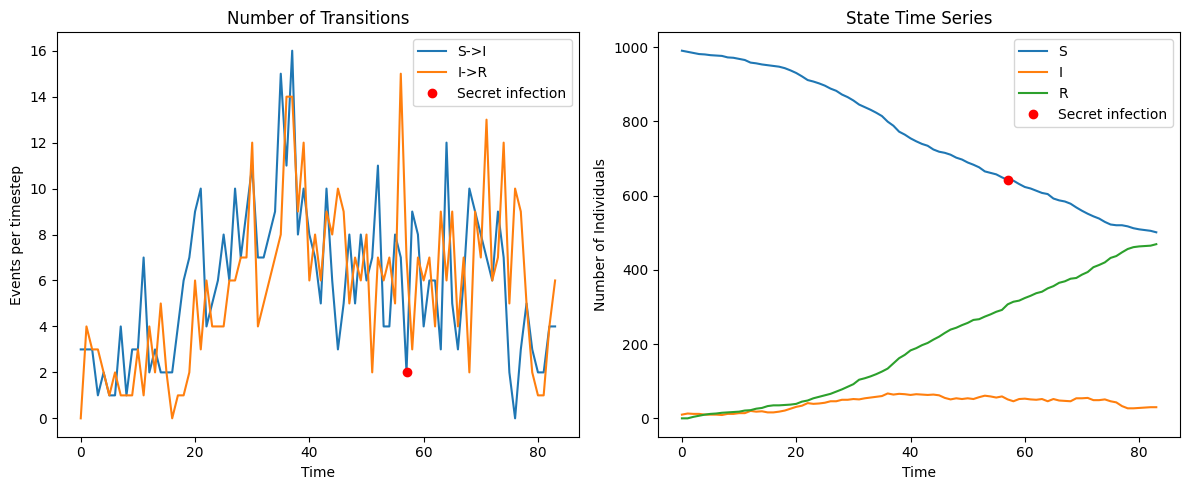

In [159]:
# Create a figure with two subplots (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# First subplot: Plot the number of transitions
ax1.plot(sir_sim[:, 0, 0], label='S->I')
ax1.plot(sir_sim[:, 0, 1], label='I->R')
ax1.plot(57, sir_sim[57,0,0],'o', label="Secret infection", color = 'r')
ax1.legend()
ax1.set_xlabel("Time")
ax1.set_ylabel("Events per timestep")
ax1.set_title("Number of Transitions")

# Second subplot: Plot the curves
state_timeseries = sir.compute_state(events=sir_sim)
ax2.plot(state_timeseries[:, 0, 0], label="S")
ax2.plot(state_timeseries[:, 0, 1], label="I")
ax2.plot(state_timeseries[:, 0, 2], label="R")
ax2.plot(57,state_timeseries[57, 0, 0], 'o', label="Secret infection", color = 'r')
ax2.legend()
ax2.set_xlabel("Time")
ax2.set_ylabel("Number of Individuals")
ax2.set_title("State Time Series")

# Adjust layout to prevent overlap
plt.tight_layout()

# Display the plots
plt.show()

This begs the question
> How does this impact the epidemic?

If we think back to the likelihood evaluation sessions, we rely on a $\delta t_s$ component. Adding or deleting an event in the dataset will have a domino effect on other events around it because it _will_ impact the transition rates (and by extension the transition probabilities) at a given time. Running a data augmentation MCMC algorithm could let us catch events that the data recording process may have missed. The intuition for this is that for a given parameter set $\theta$, adding (or deleting) an event results in a more probable trajectory of the epidemic.

### `gemlib` implementation

Implementing these samplers from scratch is a challenging data engineering exercise since each type of move would result in a reordering and reshaping of the events that make up an epidemic. We've seen the additional steps needed for the move event sampler to work and the equivalent add/delete samplers are similar (though slightly more involved in order to manage the shape of the data to ensure we can still compile our code in XLA mode).

`gemlib` has already implemented several algorithms to do this for us. The remainder of this session will be time to experiment with these samplers and create your very own bespoke, compound MCMC algorithms which estimate parameter values _and_ missing data.

In [160]:
# import samplers we will use
from gemlib.mcmc.discrete_time_state_transition_model import move_events
from gemlib.mcmc.discrete_time_state_transition_model import right_censored_events_mh
from gemlib.mcmc.discrete_time_state_transition_model import left_censored_events_mh
from gemlib.mcmc.mcmc_sampler import mcmc
from gemlib.mcmc.mwg_step import MwgStep

In [161]:
@tfd.JointDistributionCoroutineAutoBatched
def sir_da_model():
    initial_conditions = yield tfd.Sample(
        tfd.Multinomial(
            1000,
            probs=np.array([[0.90, 0.1, 0.0], [0.999, 0.001, 0.0]]),
        ),
        name="initial_conditions",
    )

    sir = yield DiscreteTimeStateTransitionModel(
        transition_rate_fn=make_transition_rate_fn(beta=0.2, gamma=0.14),
        incidence_matrix=incidence_matrix,
        initial_state=initial_conditions,
        num_steps=84,
        name="sir",
    )
 

In [162]:
move_kernel = MwgStep(
    move_events(
        incidence_matrix=incidence_matrix,
        transition_index=0,
        num_units=1,
        delta_max=5,
        count_max=10,
    ),
    target_names="sir",
    kernel_kwargs_fn=lambda p: {"initial_conditions": p.initial_conditions},
)

right_censored_kernel = MwgStep(
    right_censored_events_mh(
        incidence_matrix=incidence_matrix,
        transition_index=0,
        count_max=10,
        t_range=(84 - 14, 84),  # Just add/del for the last 2 weeks of the epidemic
    ),
    target_names="sir",
    kernel_kwargs_fn=lambda p: {"initial_conditions": p.initial_conditions},
)

left_censored_events = MwgStep(
    left_censored_events_mh(
        incidence_matrix=incidence_matrix,
        transition_index=0,
        max_timepoint=10,
        max_events=5,
        events_varname="sir",
        initial_conditions_varname="initial_conditions",
    ),
    target_names=["initial_conditions", "sir"],
)

In [163]:
kernel= move_kernel >> right_censored_kernel >> left_censored_events

In [164]:
class Position(NamedTuple):
    sir: ArrayLike
    initial_conditions: ArrayLike


initial_mcmc_position = Position(
    sir=sir_sim,
    initial_conditions=initial_conditions
)

In [165]:
@jax.jit
def run_mcmc(seed):
    return mcmc(
        num_samples=10000,
        sampling_algorithm=kernel,
        target_log_density_fn=sir_da_model.log_prob,
        initial_position=initial_mcmc_position,
        seed=seed,
    )
 

In [166]:
samples, info = run_mcmc(jax.random.key(42))

In [167]:
move_acceptance_rate = info[0].is_accepted.mean()
print(f"move acceptance rate = {move_acceptance_rate:.3f}")

move acceptance rate = 0.378


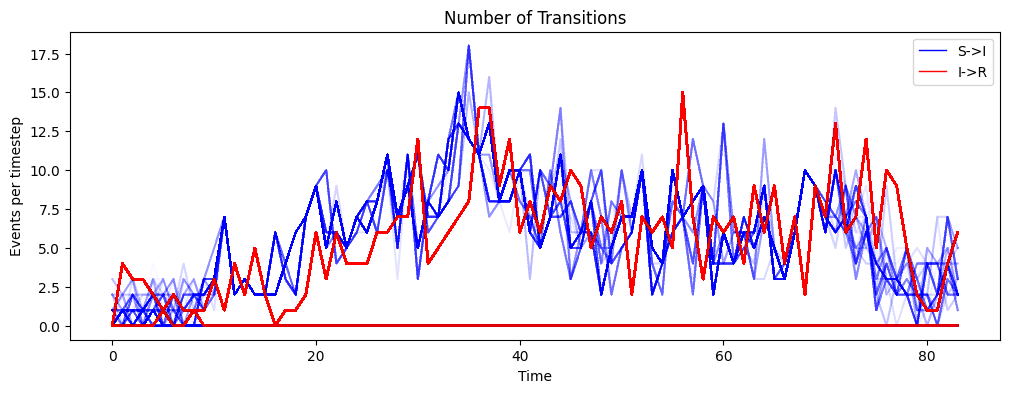

In [168]:
# @title
fig = plt.figure(figsize = [12,4])

for i in range(500):
    # plot the num SI events over time for 500 iterations of the MCMC
    plt.plot(samples[0][i][:,:,0],
             color='b',
             alpha = 0.01,
             label='S->I')
    # plot fixed events I -> R
    plt.plot(samples[0][0][:,:,1],
             color='r',
             alpha = 0.1,
             label='I->R')

legend_elements = [Line2D([0], [0], color='b', lw=1, label='S->I'),
                   Line2D([0], [0], color='r', lw=1, label='I->R'),
                   ]

plt.legend(handles=legend_elements,)
plt.xlabel("Time")
plt.ylabel("Events per timestep")
plt.title("Number of Transitions")

plt.show()

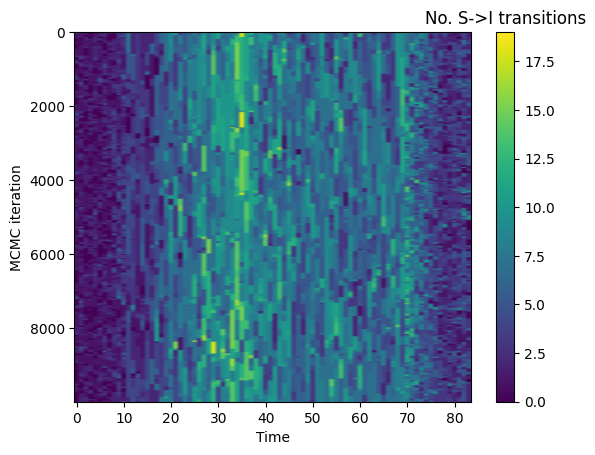

In [169]:
plt.imshow(samples.sir[:,:,0,0], aspect="auto")     # [MCMC iteration, time step, unit, num event]
plt.xlabel('Time')
plt.ylabel('MCMC iteration')
cb = plt.colorbar()
cb.ax.set_title("No. S->I transitions")
plt.show()

Text(0, 0.5, 'No. of S->I transitions')

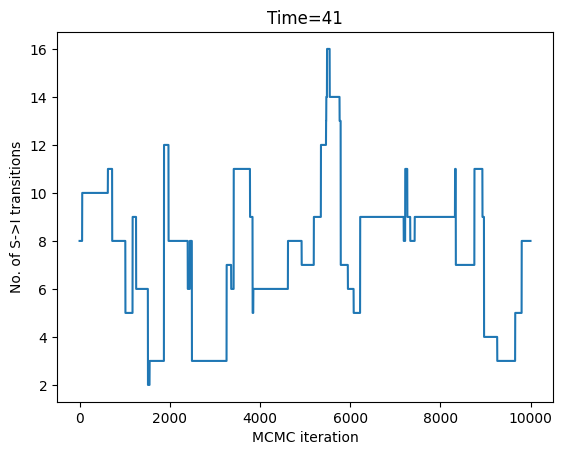

In [170]:
plt.plot(samples.sir[:,40,0,0])
plt.title("Time=41")
plt.xlabel("MCMC iteration")
plt.ylabel("No. of S->I transitions")

````{exercise-start}
:label: da-ex.2
````

If you have time, here are a few things to explore with the model and
samplers above.

1. **Change `delta_max`.** Try a much smaller or much larger value in
   `move_kernel`, what effect does that have on the samples you get
   out?
2. **Define your own model.** Re-run the simulation and
   sampler. How does the result change?

````{exercise-end}
````